In [2]:
%matplotlib inline
import matplotlib.pyplot as plt
import sys
sys.path.insert(0, "/home/jovyan/sirf-demo/.packages")
import stir_simind_utils as utils
# plotting settings
plt.ion() # interactive 'on' such that plots appear during loops
#%% Import SIRF
import sirf.STIR as spect
import numpy as np
from simind_python_connector import StirSimindAdaptor
import phantomgen as phantom
import numpy as np
import numexpr as ne
ne.set_num_threads(16) # use only 16 threads
from pathlib import Path
demo_path = Path("/home/jovyan/sirf-demo/SIRF-demo-1")

## Create the Digital NEMA Phantoms

Digital **NEMA IEC body phantoms** are created for the **Lu-177** and **Tc-99m** SPECT experiments.

For each radionuclide, we generate:

- **Activity distribution** — defines the location and activity concentration of the radioactive sources.
- **Attenuation map** — assigns the appropriate linear attenuation coefficient to each phantom material.
- **Region masks** — identify the individual spheres and other phantom regions for subsequent quantitative evaluation.

The phantoms use a **256 × 256 × 256** image matrix with **2.21 mm isotropic voxels**.  
The six spheres have diameters of **13, 17, 22, 28, 37, and 60 mm**.

The generated activity and attenuation images are converted to **SIRF/STIR `ImageData`** objects and saved for use in the subsequent simulation and reconstruction steps.

In [12]:
# Define the image grid used for the digital phantoms.
# Both phantoms are generated on a 128 × 128 × 128 grid with isotropic 4.42 mm voxels.
matrix_size = (128,) * 3
voxel_size = (4.42,) * 3


# =============================================================================
# Lu-177 NEMA SPECT phantom
# =============================================================================

# Define the Lu-177 phantom properties:
#   - attenuation coefficients (cm^-1) for the phantom materials
#   - background activity concentration
#   - lung insert configuration
#   - sphere sizes, positions, and activity concentrations
#
# The six spheres correspond to the standard NEMA IEC body phantom sphere sizes.
print("Creating Lu-177 SPECT NEMA phantom and attenuation map...")

earl_nema_dict_lu177 = {
    "mu_values":{
        "perspex_mu_value": 0.15,
        "fill_mu_value": 0.14,
        "lung_mu_value": 0.043
    },
    "activity_concentration_background": 0.0,
    "include_lung_insert": False,
    "sphere_dict": {
        "ring_R": 57,
        "ring_z": -37,
        "spheres": {
            "diametre_mm": [13,17,22,28,37,60],
            "angle_loc":   [270,150,30,90,330,210],
            "act_conc_MBq_ml": [1.611,1.611,1.611,1.611,1.611,1.611],
        }
    }
}


# Generate the activity distribution, attenuation map, and masks.
# Supersampling is used during phantom generation to improve the representation
# of curved boundaries on the voxel grid.
nema_act_lu_arr, nema_ctac_lu_arr, mask_lu_dict = phantom.create_nema(
    matrix_size=matrix_size, 
    voxel_size_mm=voxel_size, 
    nema_dict=earl_nema_dict_lu177,
    supersample=2
)


# Convert the NumPy activity array to a SIRF/STIR ImageData object
# and save it for use as the SIMIND source distribution.
nema_act_lu = spect.ImageData()
nema_act_lu.initialise(dim=matrix_size, vsize=voxel_size)
nema_act_lu.fill(nema_act_lu_arr)

source_lu_dir = demo_path / "simind_data" / "lu177_128" / "input"
source_lu_dir.mkdir(parents=True, exist_ok=True)

nema_act_lu.write(str(source_lu_dir / "nema_lu_act"))


# Create the corresponding attenuation image using the same image geometry
# and save it for attenuation modelling during simulation/reconstruction.
nema_ctac_lu = nema_act_lu.clone()
nema_ctac_lu.fill(nema_ctac_lu_arr)
nema_ctac_lu.write(str(source_lu_dir / "nema_lu_ctac"))


# Save the phantom region masks for later quantitative evaluation.
np.savez_compressed(str(source_lu_dir / "masks_lu.npz"), **mask_lu_dict)

print()


# =============================================================================
# Tc-99m NEMA SPECT phantom
# =============================================================================

# Repeat the phantom generation for Tc-99m.
# The phantom geometry is unchanged, while the attenuation coefficients
# and activity concentrations are defined for the Tc-99m experiment.
print("Creating Tc-99m SPECT NEMA phantom and attenuation map...")

earl_nema_dict_tc99m = {
    "mu_values":{
        "perspex_mu_value": 0.175,
        "fill_mu_value": 0.154,
        "lung_mu_value": 0.046
    },
    "activity_concentration_background": 0.0,
    "include_lung_insert": False,
    "sphere_dict": {
        "ring_R": 57,
        "ring_z": -37,
        "spheres": {
            "diametre_mm": [13,17,22,28,37,60],
            "angle_loc":   [270,150,30,90,330,210],
            "act_conc_MBq_ml": [1.013,1.013,1.013,1.013,1.013,1.013],
        }
    }
}


# Generate the Tc-99m activity distribution, attenuation map, and masks.
nema_act_tc_arr, nema_ctac_tc_arr, mask_tc_dict = phantom.create_nema(
    matrix_size=matrix_size, 
    voxel_size_mm=voxel_size, 
    nema_dict=earl_nema_dict_tc99m,
    supersample=3
)


# Convert and save the activity distribution as SIRF/STIR ImageData.
nema_act_tc = spect.ImageData()
nema_act_tc.initialise(dim=matrix_size, vsize=voxel_size)
nema_act_tc.fill(nema_act_tc_arr)

source_tc_dir = demo_path / "simind_data" / "tc99m_128" / "input"
source_tc_dir.mkdir(parents=True, exist_ok=True)

nema_act_tc.write(str(source_tc_dir / "nema_tc_act"))


# Create and save the corresponding attenuation image.
nema_ctac_tc = nema_act_tc.clone()
nema_ctac_tc.fill(nema_ctac_tc_arr)
nema_ctac_tc.write(str(source_tc_dir / "nema_tc_ctac"))


# Save the phantom masks for subsequent quantitative analysis.
np.savez_compressed(str(source_tc_dir / "masks_tc.npz"), **mask_tc_dict)



Creating Lu-177 SPECT NEMA phantom and attenuation map...



Creating Tc-99m SPECT NEMA phantom and attenuation map...


## Visualise the Digital NEMA Phantoms

Before running the simulations, we inspect the generated **activity distributions** and **attenuation maps**.

The saved images are loaded as **SIRF/STIR `ImageData`** objects and converted to NumPy arrays for visualisation.

For both **Lu-177** and **Tc-99m**, a transverse slice through the spheres is displayed showing:

- **Activity distribution** — the radioactive sources used as input to the SIMIND simulation.
- **Attenuation map** — the spatial distribution of linear attenuation coefficients used to model photon attenuation.

Visual inspection provides a simple check that the phantom geometry, source distribution, and attenuation map have been generated correctly before proceeding to the simulation.

(<Figure size 1200x500 with 4 Axes>,
 array([<Axes: title={'center': '99m-Tc Activity [MBq]'}>,
        <Axes: title={'center': 'Attenuation Map [cm-1]'}>], dtype=object))

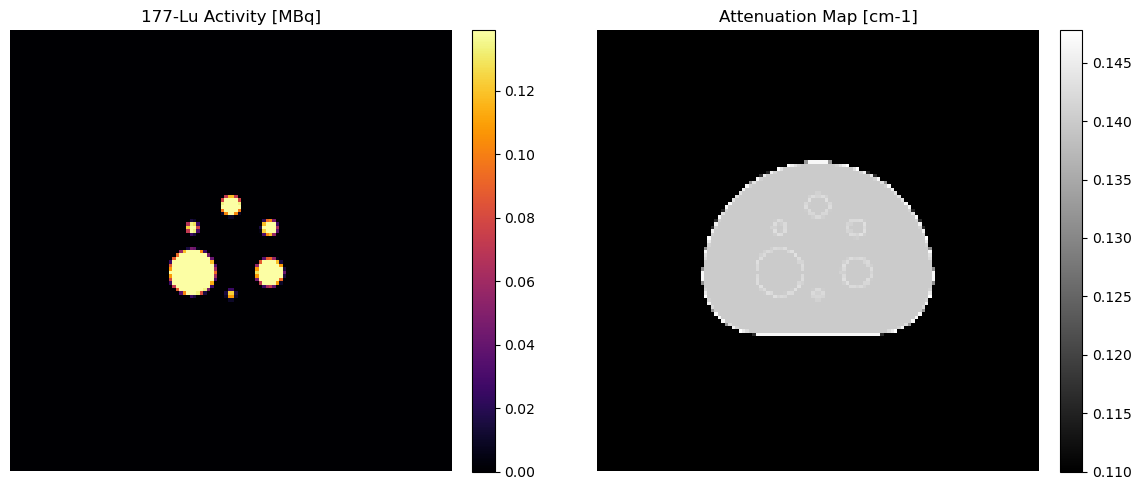

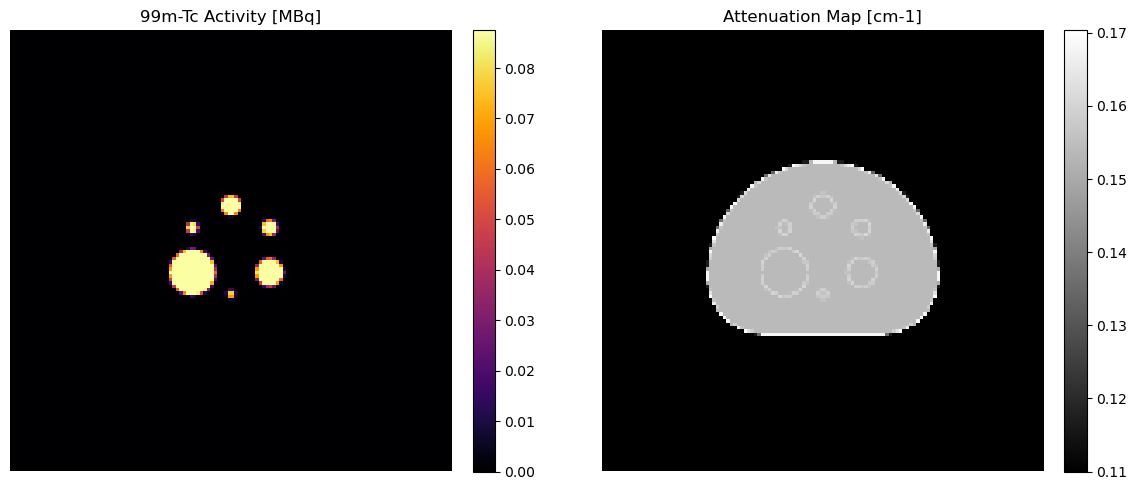

In [ ]:
nema_act_lu_arr = spect.ImageData("/home/jovyan/sirf-demo/SIRF-demo-1/simind_data/lu177_128/input/nema_lu_act.hv").as_array()
nema_ctac_lu_arr = spect.ImageData("/home/jovyan/sirf-demo/SIRF-demo-1/simind_data/lu177_128/input/nema_lu_ctac.hv").as_array()

nema_act_tc_arr = spect.ImageData("/home/jovyan/sirf-demo/SIRF-demo-1/simind_data/tc99m_128/input/nema_tc_act.hv").as_array()
nema_ctac_tc_arr = spect.ImageData("/home/jovyan/sirf-demo/SIRF-demo-1/simind_data/tc99m_128/input/nema_tc_ctac.hv").as_array()

idx = (56,slice(None),slice(None))

utils.display_arr(
    arr_3d=[nema_act_lu_arr, nema_ctac_lu_arr],
    idx=idx,
    cmap=["inferno", "gray"],
    vmin=[0, 0.11],
    titles=["177-Lu Activity [MBq]", "Attenuation Map [cm-1]"]
)

utils.display_arr(
    arr_3d=[nema_act_tc_arr, nema_ctac_tc_arr],
    idx=idx,
    cmap=["inferno", "gray"],
    vmin=[0, 0.11],
    titles=["99m-Tc Activity [MBq]", "Attenuation Map [cm-1]"]
)

## Simulate Tc-99m SPECT Projection Data with SIMIND

The digital NEMA phantom is now used as input to **SIMIND** to generate simulated SPECT projection data.

The `StirSimindAdaptor` provides an interface between **SIRF/STIR** and **SIMIND**, allowing the activity distribution and attenuation map created previously to be passed directly to the simulation.

For this Tc-99m simulation:

- The **activity image** defines the spatial distribution of the radioactive source.
- The **attenuation map** is used to model photon attenuation within the phantom.
- A **photopeak window** is defined around the 140 keV Tc-99m photopeak.
- An additional **lower-energy scatter window** is generated for subsequent scatter correction.
- The **GE Discovery 670** camera and collimator configuration is specified through the SIMIND configuration.
- A fixed random seed is used to make the simulation reproducible.

SIMIND performs the Monte Carlo simulation and returns the resulting projection data in a form that can subsequently be used by **SIRF/STIR for image reconstruction**.

In [ ]:
# for Tc99m

# -------------------------------------------------------------------------
# Define energy window
#
# Example: ±10% photopeak window around 140 keV
# 126–154 keV
#
# scatter_orders = 0 means all scatter orders are accepted by SCATTWIN.
# -------------------------------------------------------------------------

window_lower = [114.0, 126.45]  # 140 - 14 keV
window_upper = [126.0, 154.55]  # 140 + 14 keV
scatter_orders = [0,] * len(window_upper)

config_file = demo_path / "Discovery670_tc99m.yaml"

output_tc_dir = demo_path / "simind_data" / "tc99m_256" / "output"
output_tc_dir.mkdir(parents=True, exist_ok=True)

output_prefix = "tc99m_simulation"

simind = StirSimindAdaptor(
    config_source=str(config_file),
    output_dir=str(output_tc_dir),
    output_prefix=output_prefix,
    photon_multiplier=0.1,
)


# Set source and attenuation map

simind.set_source(nema_act_tc)
simind.set_mu_map(nema_ctac_tc)


# Set energy windows

simind.set_energy_windows(
    lower_bounds=window_lower,
    upper_bounds=window_upper,
    scatter_orders=scatter_orders,
)



# SIMIND runtime settings

# Tc-99m radionuclide data
simind.add_runtime_switch("FI", "tc99m")

# Discovery 670 collimator.
# Your YAML contains "ge-megp" as text variable 1.
simind.add_runtime_switch("CC", "ge-megp")

# Random seed
simind.add_runtime_switch("RR", 12345)


# -------------------------------------------------------------------------
# Run SIMIND
# -------------------------------------------------------------------------

outputs = simind.run()

INFO: Running SIMIND: simind tc99m_simulation tc99m_simulation /NN:0.1/FI:tc99m/CC:ge-megp/RR:12345/PX:0.22100000381469725


 



              SIMIND Monte Carlo Simulation Program    V8.0  
------------------------------------------------------------------------------
 Phantom S : h2o       Crystal...: nai       InputFile.: tc99m_simulation  
 Phantom B : bone      BackScatt.: pmt       OutputFile: tc99m_simulation  
 Collimator: pb_sb2    SourceRout: smap      SourceImg.: tc99m_simulation_s
 Cover.....: al        ScoreRout.: scattwin  DensityImg: tc99m_simulation_d
------------------------------------------------------------------------------
 PhotonEnergy.......: 140          tc99m     PhotonsPerProj....: 743068         
 EnergyResolution...: 12           Spectra   Activity..........: 3249.5         
 MaxScatterOrder....: 3            ge-megp   DetectorLenght....: 20             
 DetectorWidth......: 27           SPECT     DetectorHeight....: 0.9525         
 UpperEneWindowTresh: 210          x-rays    Distance to det...: 16.91          
 LowerEneWindowTresh: 70           Random    ShiftSource X.....: 0

INFO: Converted 120 radii from orbit file tc99m_simulation.cor
INFO: Successfully converted /home/jovyan/sirf-demo/SIRF-demo-1/simind_data/tc99m_256/output/tc99m_simulation_air_w1.h00 to /home/jovyan/sirf-demo/SIRF-demo-1/simind_data/tc99m_256/output/tc99m_simulation_air_w1.hs
INFO: Converted 120 radii from orbit file tc99m_simulation.cor
INFO: Successfully converted /home/jovyan/sirf-demo/SIRF-demo-1/simind_data/tc99m_256/output/tc99m_simulation_air_w2.h00 to /home/jovyan/sirf-demo/SIRF-demo-1/simind_data/tc99m_256/output/tc99m_simulation_air_w2.hs
INFO: Converted 120 radii from orbit file tc99m_simulation.cor
INFO: Successfully converted /home/jovyan/sirf-demo/SIRF-demo-1/simind_data/tc99m_256/output/tc99m_simulation_sca_w1.h00 to /home/jovyan/sirf-demo/SIRF-demo-1/simind_data/tc99m_256/output/tc99m_simulation_sca_w1.hs
INFO: Converted 120 radii from orbit file tc99m_simulation.cor
INFO: Successfully converted /home/jovyan/sirf-demo/SIRF-demo-1/simind_data/tc99m_256/output/tc99m_simu

------------------------------------------------------------------------------
 GENERAL DATA
 keV/channel........: 0.5                    CutoffEnergy......: 0              
 Photons/Bq.........: 0.88524                StartingAngle.....: 0              
 CameraOffset X.....: 0                      CoverThickness....: 0.1            
 CameraOffset Y.....: 0                      BackscatterThickn.: 0              
 MatrixSize I.......: 256                    IntrinsicResolut..: 0.55           
 MatrixSize J.......: 256                    AcceptanceAngle...: 4.02754        
 Emission type......: 2                      Initial Weight....: 3871.23665     
 NN ScalingFactor...: 0.1                    Energy Channels...: 512            
                                                                              
 SPECT DATA
 RotationMode.......: 360                    Nr of Projections.: 120            
 RotationAngle......: 3                      Projection.[start]: 1              
 Orbit

## Add Poisson Noise and Perform Scatter Correction

The SIMIND simulations generate projection data that can be used to create a more realistic SPECT acquisition.

In this step:

- **Poisson noise** is added independently to the simulated photopeak and scatter-window projections to model the statistical nature of detected photon counts.
- The noisy projections are saved as new acquisition datasets, preserving the original simulated data.
- The **lower-energy scatter window** is used to estimate the scatter contribution within the photopeak window.
- A **dual-energy window (DEW) scatter correction** is applied to produce scatter-corrected projection data.

The resulting scatter-corrected acquisition data are saved for use in the subsequent **SPECT image reconstruction**.

In [14]:
output_tc_dir = Path("/home/jovyan/sirf-demo/SIRF-demo-1/simind_data/tc99m_128/output")
output_prefix = "tc99m_simulation"

pp_path = output_tc_dir / f"{output_prefix}_tot_w2.hs"
sc_path = output_tc_dir / f"{output_prefix}_tot_w1.hs"

tomo_tc_dir = demo_path / "simind_data" / "tc99m_128" / "tomo"
tomo_tc_dir.mkdir(parents=True, exist_ok=True)

pp_path_noisy = tomo_tc_dir / f"{output_prefix}_em_noisy.hs"
sc_path_noisy = tomo_tc_dir / f"{output_prefix}_sc_noisy.hs"

utils.acq_poisson_noise(
    hs_file=pp_path,
    save_path=pp_path_noisy
)

utils.acq_poisson_noise(
    hs_file=sc_path,
    save_path=sc_path_noisy
)

acq_tc_dew = utils.scatter_correction(
    PP_hdr=str(pp_path_noisy),
    SC1_hdr=str(sc_path_noisy)
)

dew_path = tomo_tc_dir / f"{output_prefix}_dew.hs"
acq_tc_dew.write(str(dew_path)[:-3])

Photopeak window width: 28.1
Scatter window width: 12.0
Scatter fraction: 1.17


## Visualise the Simulated Projection Data

The simulated SPECT projection data are inspected before proceeding to image reconstruction.

For the **photopeak (EM)** and **scatter (SC)** energy windows, the original SIMIND projections are displayed alongside the corresponding projections after the addition of **Poisson noise**. The same intensity scale is used for each pair to allow direct visual comparison.

The resulting **dual-energy window (DEW) scatter-corrected** projections are also displayed.

This allows us to visually assess the effect of **counting statistics** and **scatter correction** on the projection data that will be used for reconstruction.

(<Figure size 600x500 with 2 Axes>, <Axes: title={'center': 'Tc99m DEW'}>)

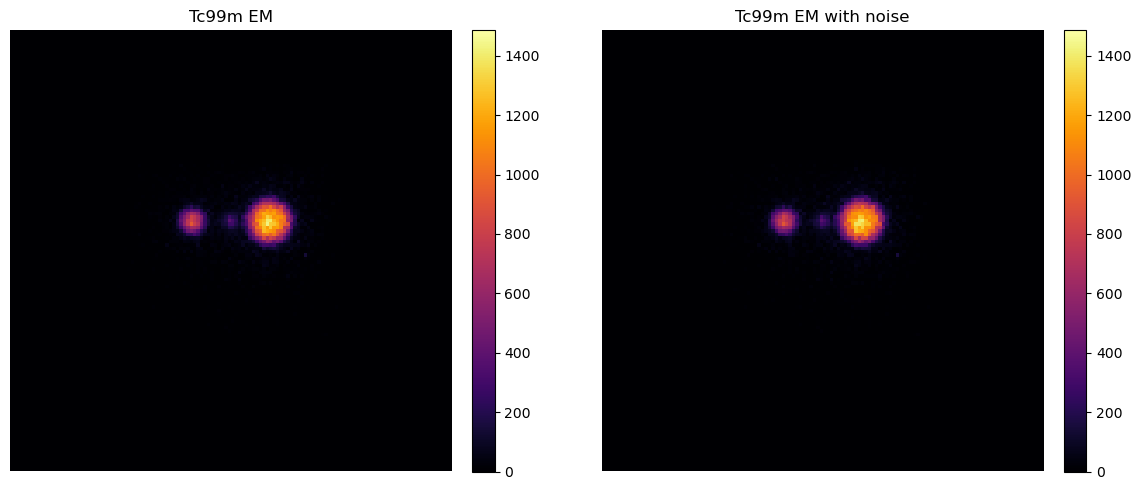

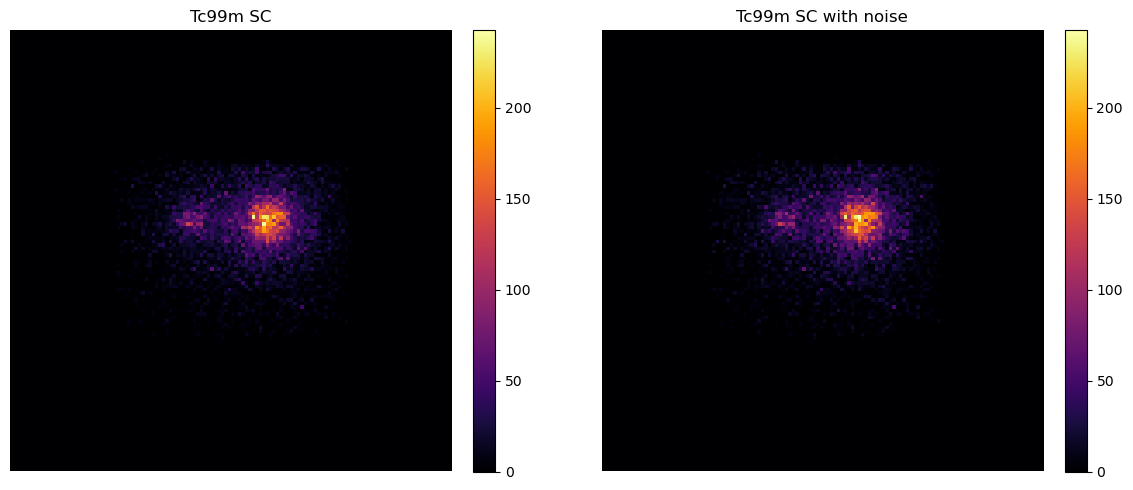

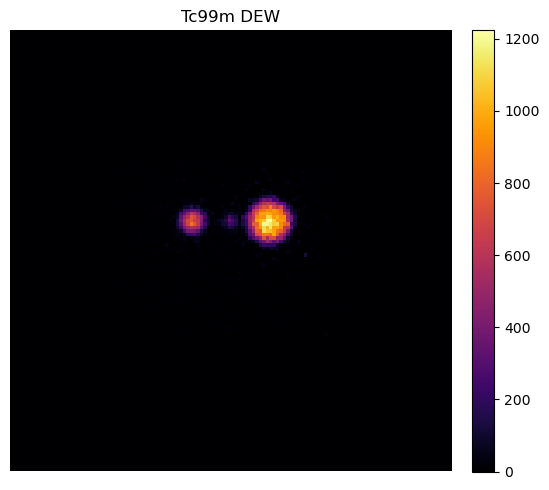

In [15]:
idx = (slice(None), 60, slice(None))
vmax = np.max(spect.AcquisitionData(str(pp_path)).as_array()[0,:])

utils.display_arr(
    arr_3d=[spect.AcquisitionData(str(pp_path)).as_array()[0,:], spect.AcquisitionData(str(pp_path_noisy)).as_array()[0,:]],
    idx=idx,
    titles=["Tc99m EM", "Tc99m EM with noise"],
    vmax=[vmax, vmax],
    vmin =[0, 0]
)

vmax = np.max(spect.AcquisitionData(str(sc_path)).as_array()[0,:])
utils.display_arr(
    arr_3d=[spect.AcquisitionData(str(sc_path)).as_array()[0,:], spect.AcquisitionData(str(sc_path_noisy)).as_array()[0,:]],
    idx=idx,
    titles=["Tc99m SC", "Tc99m SC with noise"],
    vmax=[vmax, vmax],
    vmin=[0, 0]
)

utils.display_arr(
    arr_3d=spect.AcquisitionData(str(dew_path)).as_array()[0,:],
    idx=idx,
    titles="Tc99m DEW"
)

## Simulate Lu-177 SPECT Projection Data with SIMIND

The same simulation workflow is now applied to the **Lu-177 NEMA phantom**.

The activity distribution and attenuation map are passed from **SIRF/STIR** to **SIMIND** using the `StirSimindAdaptor`.

For this Lu-177 simulation:

- The main **photopeak window** is centred on the 208 keV emission of Lu-177.
- **Lower and upper scatter windows** are simulated for subsequent scatter estimation and correction.
- The **GE Discovery 670** camera and collimator configuration is specified through the SIMIND configuration.
- A fixed random seed is used to make the simulation reproducible.

SIMIND generates the projection data for each energy window, which will subsequently be used to produce noisy, scatter-corrected acquisition data for **SPECT image reconstruction**.

In [ ]:
# for Lu177m

# -------------------------------------------------------------------------
# Define energy window
#
# Example: ±10% photopeak window around 208 keV
# 187.2–228.8 keV
#
# scatter_orders = 0 means all scatter orders are accepted by SCATTWIN.
# -------------------------------------------------------------------------

window_lower = [187.2, 156.4, 229.36] # keV
window_upper = [228.8, 183.6, 258.64] # keV
scatter_orders = [0,] * len(window_upper)

config_file = demo_path / "Discovery670_lu177.yaml"

output_lu_dir = demo_path / "simind_data" / "lu177_128" / "output"
output_lu_dir.mkdir(parents=True, exist_ok=True)

output_prefix = "lu177_simulation"

simind = StirSimindAdaptor(
    config_source=str(config_file),
    output_dir=str(output_lu_dir),
    output_prefix=output_prefix,
    photon_multiplier=0.1,
)


# Set source and attenuation map

simind.set_source(nema_act_lu)
simind.set_mu_map(nema_ctac_lu)


# Set energy windows

simind.set_energy_windows(
    lower_bounds=window_lower,
    upper_bounds=window_upper,
    scatter_orders=scatter_orders,
)



# SIMIND runtime settings

# Lu-177 radionuclide data
simind.add_runtime_switch("FI", "lu177")

# Discovery 670 collimator.
# Your YAML contains "ge-megp" as text variable 1.
simind.add_runtime_switch("CC", "ge-megp")

# Random seed
simind.add_runtime_switch("RR", 12345)


# -------------------------------------------------------------------------
# Run SIMIND
# -------------------------------------------------------------------------

outputs = simind.run()



INFO: Running SIMIND: simind lu177_simulation lu177_simulation /NN:0.1/FI:lu177/CC:ge-megp/RR:12345/PX:0.22100000381469725


 



              SIMIND Monte Carlo Simulation Program    V8.0  
------------------------------------------------------------------------------
 Phantom S : h2o       Crystal...: nai       InputFile.: lu177_simulation  
 Phantom B : bone      BackScatt.: pmt       OutputFile: lu177_simulation  
 Collimator: pb_sb2    SourceRout: smap      SourceImg.: lu177_simulation_s
 Cover.....: al        ScoreRout.: scattwin  DensityImg: lu177_simulation_d
------------------------------------------------------------------------------
 PhotonEnergy.......: 208          lu177     PhotonsPerProj....: 743068         
 EnergyResolution...: 12           Spectra   Activity..........: 11110          
 MaxScatterOrder....: 3            ge-megp   DetectorLenght....: 20             
 DetectorWidth......: 27           SPECT     DetectorHeight....: 0.9525         
 UpperEneWindowTresh: 312          x-rays    Distance to det...: 16.91          
 LowerEneWindowTresh: 104          Random    ShiftSource X.....: 0

INFO: Converted 120 radii from orbit file lu177_simulation.cor
INFO: Successfully converted /home/jovyan/sirf-demo/SIRF-demo-1/simind_data/lu177_256/output/lu177_simulation_air_w1.h00 to /home/jovyan/sirf-demo/SIRF-demo-1/simind_data/lu177_256/output/lu177_simulation_air_w1.hs
INFO: Converted 120 radii from orbit file lu177_simulation.cor
INFO: Successfully converted /home/jovyan/sirf-demo/SIRF-demo-1/simind_data/lu177_256/output/lu177_simulation_air_w2.h00 to /home/jovyan/sirf-demo/SIRF-demo-1/simind_data/lu177_256/output/lu177_simulation_air_w2.hs
INFO: Converted 120 radii from orbit file lu177_simulation.cor
INFO: Successfully converted /home/jovyan/sirf-demo/SIRF-demo-1/simind_data/lu177_256/output/lu177_simulation_air_w3.h00 to /home/jovyan/sirf-demo/SIRF-demo-1/simind_data/lu177_256/output/lu177_simulation_air_w3.hs
INFO: Converted 120 radii from orbit file lu177_simulation.cor
INFO: Successfully converted /home/jovyan/sirf-demo/SIRF-demo-1/simind_data/lu177_256/output/lu177_simu

------------------------------------------------------------------------------
 GENERAL DATA
 keV/channel........: 1                      CutoffEnergy......: 0              
 Photons/Bq.........: 0.2264                 StartingAngle.....: 0              
 CameraOffset X.....: 0                      CoverThickness....: 0.1            
 CameraOffset Y.....: 0                      BackscatterThickn.: 0              
 MatrixSize I.......: 256                    IntrinsicResolut..: 0.55           
 MatrixSize J.......: 256                    AcceptanceAngle...: 4.02754        
 Emission type......: 2                      Initial Weight....: 3384.99542     
 NN ScalingFactor...: 0.1                    Energy Channels...: 512            
                                                                              
 SPECT DATA
 RotationMode.......: 360                    Nr of Projections.: 120            
 RotationAngle......: 3                      Projection.[start]: 1              
 Orbit

## Add Poisson Noise and Perform Lu-177 Scatter Correction

The simulated Lu-177 projections are processed to produce realistic acquisition data for reconstruction.

In this step:

- **Poisson noise** is added independently to the photopeak and both scatter-window projections to model photon-counting statistics.
- The noisy projections are saved separately, preserving the original SIMIND simulation data.
- The **lower and upper scatter windows** are used to estimate the scatter contribution within the photopeak window.
- A **triple-energy window (TEW) scatter correction** is applied to the noisy projection data.

The resulting TEW scatter-corrected acquisition data are saved for use in the subsequent **Lu-177 SPECT image reconstruction**.

In [17]:
output_lu_dir = Path("/home/jovyan/sirf-demo/SIRF-demo-1/simind_data/lu177_128/output")
output_prefix = "lu177_simulation"

pp_path = output_lu_dir / f"{output_prefix}_tot_w1.hs"
sc1_path = output_lu_dir / f"{output_prefix}_tot_w2.hs"
sc2_path = output_lu_dir / f"{output_prefix}_tot_w3.hs"

tomo_lu_dir = demo_path / "simind_data" / "lu177_128" / "tomo"
tomo_lu_dir.mkdir(parents=True, exist_ok=True)

pp_path_noisy = tomo_lu_dir / f"{output_prefix}_em_noisy.hs"
sc1_path_noisy = tomo_lu_dir / f"{output_prefix}_sc1_noisy.hs"
sc2_path_noisy = tomo_lu_dir / f"{output_prefix}_sc2_noisy.hs"

utils.acq_poisson_noise(
    hs_file=pp_path,
    save_path=pp_path_noisy
)

utils.acq_poisson_noise(
    hs_file=sc1_path,
    save_path=sc1_path_noisy
)

utils.acq_poisson_noise(
    hs_file=sc2_path,
    save_path=sc2_path_noisy
)

acq_lu_tew = utils.scatter_correction(
    PP_hdr=str(pp_path_noisy),
    SC1_hdr=str(sc1_path_noisy),
    SC2_hdr=str(sc2_path_noisy)
)

tew_path = tomo_lu_dir / f"{output_prefix}_tew.hs"
acq_lu_tew.write(str(tew_path)[:-3])

Second Scatter Window present. Performing TEW...
Photopeak window width: 41.6
Scatter window 1 width: 27.2
Scatter window 2 width: 29.28


(<Figure size 600x500 with 2 Axes>, <Axes: >)

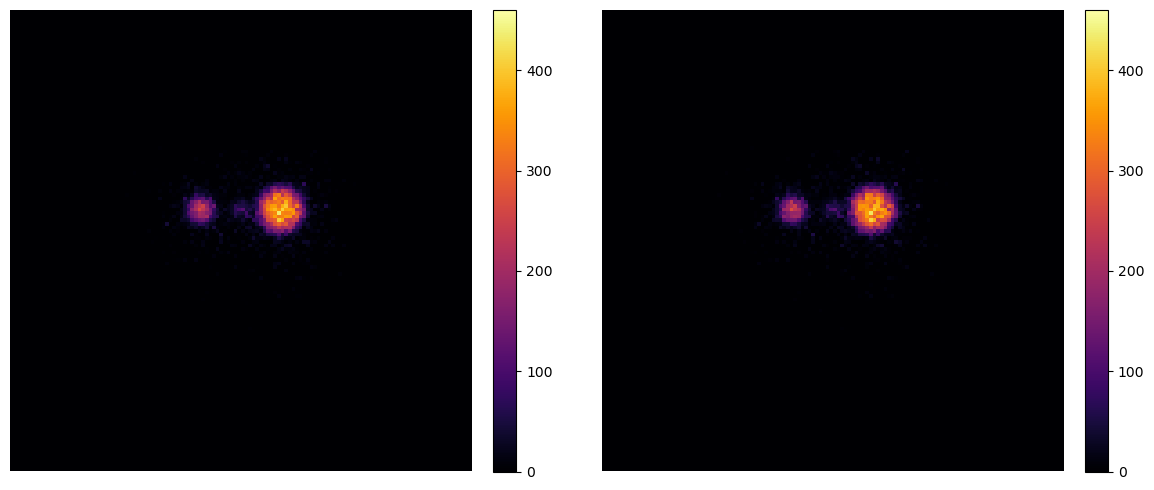

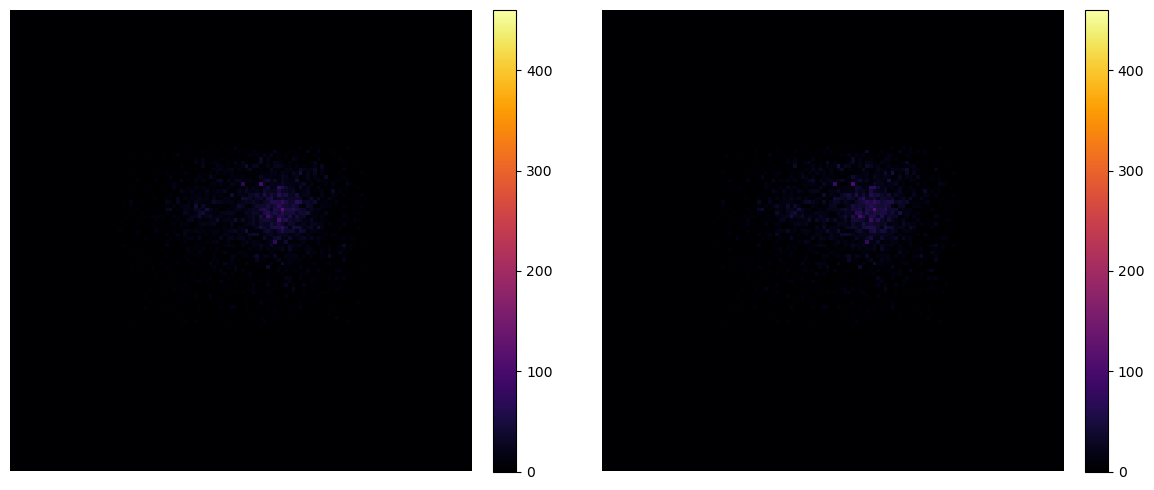

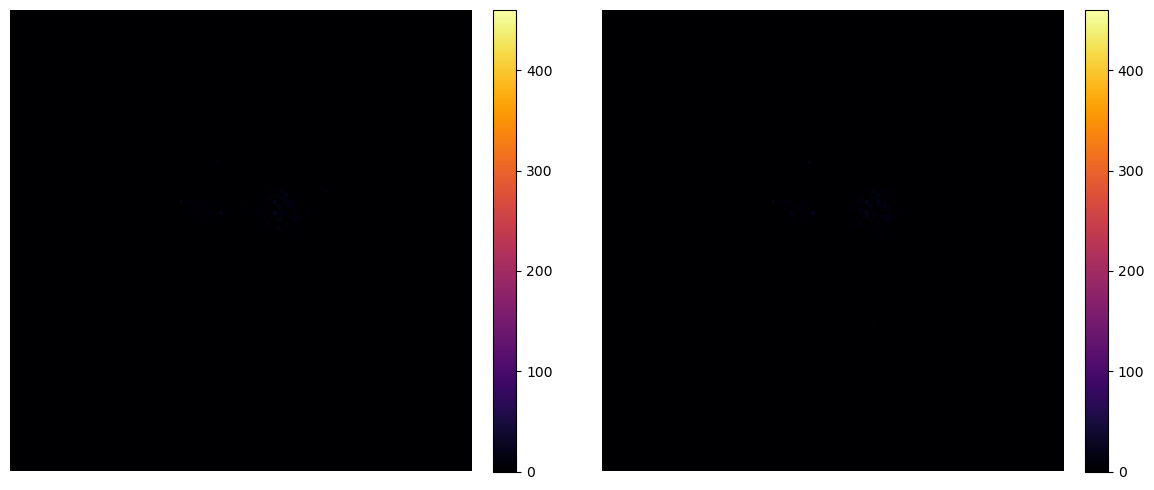

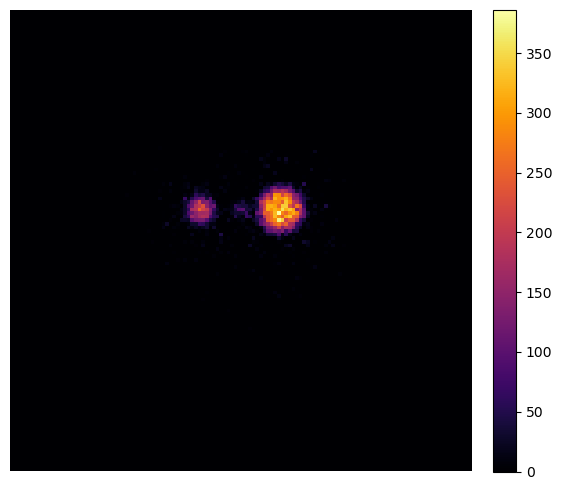

In [18]:
idx = (slice(None), 60, slice(None))
vmax = np.max(spect.AcquisitionData(str(pp_path)).as_array()[0,:])

utils.display_arr(
    arr_3d=[spect.AcquisitionData(str(pp_path)).as_array()[0,:], spect.AcquisitionData(str(pp_path_noisy)).as_array()[0,:]],
    idx=idx,
    vmax=[vmax, vmax],
    vmin=[0, 0]
)

utils.display_arr(
    arr_3d=[spect.AcquisitionData(str(sc1_path)).as_array()[0,:], spect.AcquisitionData(str(sc1_path_noisy)).as_array()[0,:]],
    idx=idx,
    vmax=[vmax, vmax],
    vmin=[0, 0]
)

utils.display_arr(
    arr_3d=[spect.AcquisitionData(str(sc2_path)).as_array()[0,:], spect.AcquisitionData(str(sc2_path_noisy)).as_array()[0,:]],
    idx=idx,
    vmax=[vmax, vmax],
    vmin=[0, 0]
)

utils.display_arr(
    arr_3d=spect.AcquisitionData(str(tew_path)).as_array()[0,:],
    idx=idx
)